# ADE Surfaces: Del Pezzo and Anticanonical Log Pairs

This pedagogical notebook defines, explores, and generates the publication figures for **ADE surfaces** following:

> **V. Alexeev, A. Thompson**, *"ADE surfaces and their moduli"* (2021, arXiv:1712.07932).

---

## 1. Mathematical Framework: Covering Pairs

ADE surfaces come in covering pairs:
$$\pi: (X, D + \varepsilon R) \longrightarrow (Y, C + \frac{1+\varepsilon}{2} B)$$

### A. The Del Pezzo ADE Surface Pair $(Y, C + \frac{1+\varepsilon}{2} B)$
1. **Toric Base $Y = V_Q$**: The 2D projective toric variety defined by the normal fan $\Sigma_Q$ of the integral lattice polytope $Q \subset N$.
2. **Boundary Divisor $C$ (The "Blue Line")**: Supported on the **distinguished edges** of $Q$ incident to $p_*$.
3. **Branch Divisor $B = \text{div}(f)$**: Defined by the section $f(x, y)$ with Newton polytope $Q$, parameterized by fundamental characters $c_i = \chi(\varpi_i)$ at diagram nodes (Eq. 3.4--3.6).

### B. The Anticanonical ADE Surface Pair $(X, D + \varepsilon R)$
1. **Ambient 3D Toric Threefold $V_P$**: Associated with the pyramidal polytope $P = \text{cone}(Q) + (p_*, 2) \subset N_3$.
2. **Anticanonical Surface $X$**: The hypersurface $X = Z(z^2 + f(x, y)) \subset V_P$. This is the **branched double cover** $\pi: X \to Y$ branched along $B$.
3. **Boundary Divisor $D \subset X$**: The preimage $D = \pi^*(C)$ of the blue line $C$.
4. **Del Pezzo Involution $\iota_{\text{dP}}$**: The involution $z \mapsto -z$ on $X$, with quotient $X / \iota_{\text{dP}} = Y$.

## 2. Category Integration in SageMath

The preamble category module `dzack_research.preamble.categories.schemes.ade_surfaces` defines the Sage category hierarchy:
```
Objects()
  └── LogPairs()         # Generic category of log pairs
      └── ADELogPairs()  # Category of ADE log pairs (Y, C, B) and (X, D)
```

In [6]:
from sage.all import *
from dzack_research.preamble.categories.schemes.ade_surfaces import (
    LogPairs,
    ADELogPairs,
    ADESurface,
    SideDecoration,
)

show(LogPairs())
show(ADELogPairs())


Category of log pairs
Category of a d e surfaces (Y, C)


## 3. Constructing Pure & Primed ADE Surfaces

`ADESurface` is instantiated using Dynkin letter, rank, and a **tuple of side decorations** for sides adjacent to $p_*$.

In [7]:
# Construct sample surfaces
A3 = ADESurface("A", 3, variant=("long", "long"))
A3_prime = ADESurface("A", 3, variant=("primed",))
D4 = ADESurface("D", 4)
D4_prime = ADESurface("D", 4, variant=("primed",))
E6 = ADESurface("E", 6)
E8 = ADESurface("E", 8)
tilde_E8 = ADESurface("E", 8, affine=True)

# Evaluating the 3D ADE covering surface hypersurface X renders its 3D LaTeX description and interactive 3D Three.js cover polytope P
A3

ADE Surface of type A_3 (hypersurface X ⊂ V_P, p* = (0, 2))

In [8]:
# Evaluating the 2D base del Pezzo log pair renders its 2D LaTeX description and 2D polygon plot of Q
A3.base()

Del Pezzo Base Surface for A_3 (Y = V_Q, C = V(z0) + V(z2), p* = (0, 2))

## 4. Universal Parametric Branch Polynomials $f(x, y; c_i)$

Following Section 3.1, Equations (3.4)--(3.6) of Alexeev-Thompson [AT21], the universal branch curve equations $B = \text{div}(f)$ are parameterized by fundamental characters $c = \chi(\varpi_i)$ on the root lattice:
- $\mathbf{A_n'}: f(x, y) = -\left(\frac{xy - c''}{2}\right)^2 + y + c_0 + c_1 x + \dots + x^{n-1}$
- $\mathbf{D_n}: f(x, y) = -\left(\frac{xy - c''}{2}\right)^2 + y^2 + c_1' y + c_0 + c_1 x + \dots + x^{n-2}$
- $\mathbf{E_n}: f(x, y) = -\left(\frac{xy - c''}{2}\right)^2 + y^3 + c_2' y^2 + c_1' y + c_0 + \dots + x^{n-3}$

In [9]:
show(A3.parametric_branch_polynomial())
show(D4.parametric_branch_polynomial())
show(E6.parametric_branch_polynomial())
show(E8.parametric_branch_polynomial())


-1/4*x^2*y^2 + 1/2*x*y*c_pp + x^2 + x*c1 - 1/4*c_pp^2 + y + c2
-1/4*x^2*y^2 + 1/2*x*y*c_pp + x^2 + y^2 + x*c1 + y*cp1 - 1/4*c_pp^2 + c2
-1/4*x^2*y^2 + x^3 + y^3 + x^2*c1 + y^2*cp1 + 1/2*x*y*c_pp + x*c2 + y*cp2 - 1/4*c_pp^2 + c3
x^5 + x^4*c1 - 1/4*x^2*y^2 + x^3*c2 + y^3 + x^2*c3 + y^2*cp1 + 1/2*x*y*c_pp + x*c4 + y*cp2 - 1/4*c_pp^2 + c5


## 5. Interior Dynkin Diagram Trees in Polytopes

Following Notation 821--838 of [AT21], the Dynkin diagram is embedded directly inside the polytope $Q$:
- Boundary nodes along $\partial Q \setminus C$: colored black (lattice length 2 from $p_*$) or white (lattice length 1 from $p_*$).
- Internal nodes for corners not in $C$: circled white nodes connected diagonally to the corner.

In [10]:
for s in [A3, D4, E6, E8]:
    show(s.base().plot(show_dynkin_diagram=True))

Graphics object consisting of 34 graphics primitives
Graphics object consisting of 28 graphics primitives
Graphics object consisting of 32 graphics primitives
Graphics object consisting of 36 graphics primitives


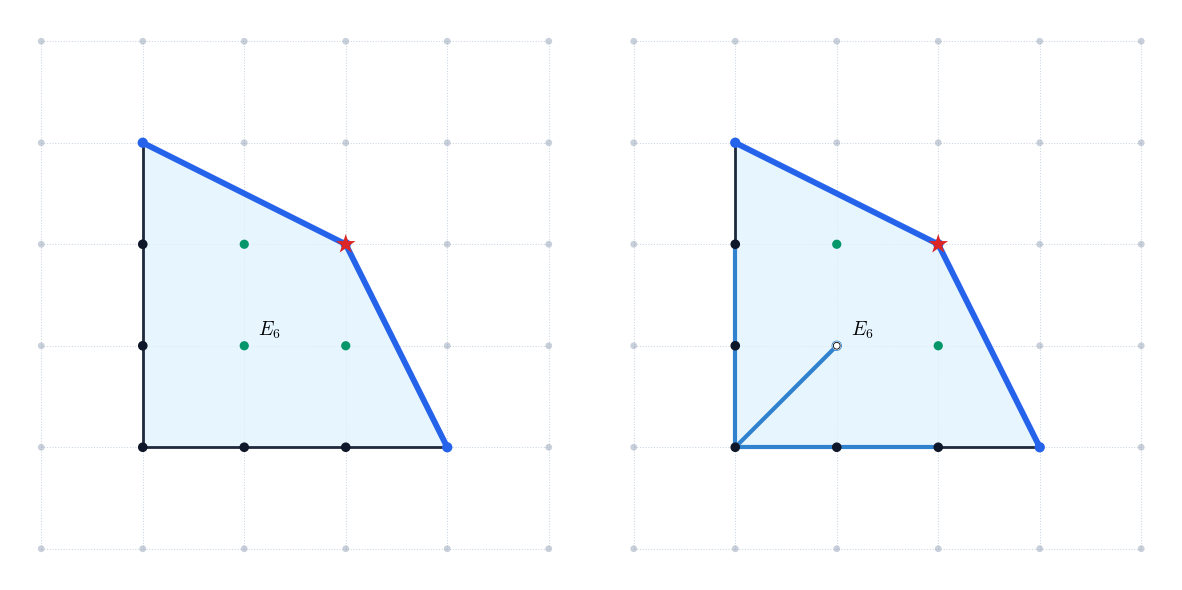

In [6]:
from sage.plot.multigraphics import GraphicsArray

p_e6_plain = E6.base().plot(show_dynkin_diagram=False)
p_e6_dynkin = E6.base().plot(show_dynkin_diagram=True)

GraphicsArray([[p_e6_plain, p_e6_dynkin]]).show(figsize=[12, 6])

## 6. Generating the Complete 12-Polytope Publication Gallery & Assets

Construct all 12 canonical ADE surfaces, render the full $4 \times 3$ publication gallery, and export all standalone vector PDF and raster PNG files to `ade_polytopes_publication/`.

In [12]:
import os
from sage.plot.multigraphics import GraphicsArray

CANONICAL_SURFACES = [
    # Row 1: A-types
    ADESurface('A', 3, variant=('long', 'long')),
    ADESurface('A', 2, variant=('long', 'short')),
    ADESurface('A', 1, variant=('short', 'long')),
    # Row 2: D4, E6, ^-E7
    ADESurface('D', 4),
    ADESurface('E', 6),
    ADESurface('E', 7, variant=('decorated',)),
    # Row 3: E8, affine D6, affine E6
    ADESurface('E', 8),
    ADESurface('D', 6, affine=True),
    ADESurface('E', 6, affine=True),
    # Row 4: affine E7, affine E8, affine A3
    ADESurface('E', 7, affine=True),
    ADESurface('E', 8, affine=True),
    ADESurface('A', 3, affine=True),
]

pub_dir = 'ade_polytopes_publication'
os.makedirs(pub_dir, exist_ok=True)

for f in os.listdir(pub_dir):
    if f.endswith(('.pdf', '.png')):
        os.remove(os.path.join(pub_dir, f))

plots = []
for s in CANONICAL_SURFACES:
    p = s.base().plot()
    plots.append(p)
    pdf_path = os.path.join(pub_dir, f"{s.key()}.pdf")
    png_path = os.path.join(pub_dir, f"{s.key()}.png")
    p.save(pdf_path, axes=False, frame=False, figsize=[8, 8])
    p.save(png_path, axes=False, frame=False, figsize=[8, 8])
    print(f"  ✓ Exported {s.key()}")

gallery = GraphicsArray([
    plots[0:3],
    plots[3:6],
    plots[6:9],
    plots[9:12],
])

gallery.save('ade-gallery.pdf', axes=False, frame=False, figsize=[18, 24])
gallery.save('ade_gallery.png', axes=False, frame=False, figsize=[18, 24])
print("\n  ✓ Exported ade-gallery.pdf and ade_gallery.png")

gallery.show(figsize=[18, 24])

  ✓ Exported A_3
  ✓ Exported A_2_minus


  ✓ Exported minus_A_1
  ✓ Exported D_4
  ✓ Exported E_6


  ✓ Exported minus_E_7
  ✓ Exported E_8
  ✓ Exported tilde_D_6


  ✓ Exported tilde_E_6
  ✓ Exported tilde_E_7
  ✓ Exported tilde_E_8


  ✓ Exported tilde_A_3



  ✓ Exported ade-gallery.pdf and ade_gallery.png
Graphics Array of size 4 x 3
